
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def Laplace2D_FDM(V_ini: np.ndarray, tol: float, Nmax_iter: int) -> np.ndarray:
    """
    Resuelve la ecuación de Laplace 2D por diferencias finitas (método de Jacobi).

    V_ini: matriz 2D con las condiciones iniciales/de frontera -> np.ndarray
    tol: tolerancia de convergencia -> float
    Nmax_iter: número máximo de iteraciones -> int

    Retorna -> np.ndarray: campo u(x,y) resultante
    """
    Nmax = V_ini.shape[0]
    V = V_ini.copy()
    
    for it in range(Nmax_iter):
        V_old = V.copy()
        
        # Algoritmo visto en clase
        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                V[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])
        
        # diferencia máxima respecto al paso anterior
        diff = np.max(np.abs(V - V_old))
        
        # Si el cambio es menor que la tolerancia, detenemos el ciclo
        if diff < tol:
            print(f"Convergió en {it + 1} iteraciones")
            return V
            
    print("Número máximo de iteraciones sin cumplir la tolerancia")
    return V


def grid(V_ini: np.ndarray, x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Construye la malla 2D y extrae el campo sobre esa malla.

    V_ini: matriz 2D con el campo u(x,y) -> np.ndarray
    x: vector de coordenadas en x -> np.ndarray
    y: vector de coordenadas en y -> np.ndarray

    Retorna -> tuple[np.ndarray, np.ndarray, np.ndarray]: X, Y, Z
    """
    V = V_ini.copy()
    X, Y = np.meshgrid(x, y)
    Z = V[X, Y]  # filed value
    # return grid
    return X, Y, Z

Número máximo de iteraciones sin cumplir la tolerancia


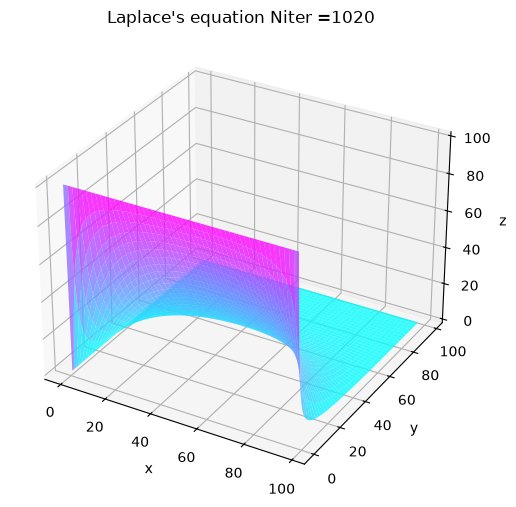

In [8]:
Nmax, Niter = 100, 1020 # Número de puntos y número máximo de iteraciones

# Matriz inicial con condiciones de frontera
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # interior a 100 V

# grid
x = np.arange(0, Nmax-1, 1)
y = x

#  Laplace2D rutina
V = Laplace2D_FDM(V_ini, tol=10e-3, Nmax_iter=Niter)
X,Y,Z = grid(V,x,y)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

Recordando que la serie de Fourier que resuelve la ecuación de Laplace en este dominio, satisfaciendo las condiciones de frontera $u(0,y)=u(L,y)=u(x,L)=0$, está dada por:

$$u(x,y)=\sum_{n=1,3,5,\dots}^{\infty}\frac{4V_0}{n\pi\,\sinh(n\pi)}\sin\!\left(\frac{n\pi x}{L}\right)\sinh\!\left(\frac{n\pi(L-y)}{L}\right)$$

donde solo contribuyen los términos con $n$ impar, ya que los términos pares se anulan al proyectar la condición de frontera constante $V_0$ sobre las funciones $\sin(n\pi x/L)$.

In [ ]:
def Laplace2D_Fourier(X: np.ndarray, Y: np.ndarray, V0: float, L: float, Nterms: int) -> np.ndarray:
    """
    Solución analítica de Laplace 2D por series de Fourier.
    X, Y: mallas 2D (np.meshgrid) con las coordenadas
    Nterms: número de términos IMPARES a sumar (n=1,3,5,...)
    """
    u = np.zeros_like(X)
    for k in range(Nterms):
        n = 2*k + 1  # solo términos impares
        coef = 4*V0 / (n*np.pi*np.sinh(n*np.pi))
        u += coef * np.sin(n*np.pi*X/L) * np.sinh(n*np.pi*(L - Y)/L)
    return u

L = 1.0
V0 = 100.0
Npts = 50  # resolución de la malla para evaluar la serie
x = np.linspace(0, L, Npts)
y = np.linspace(0, L, Npts)
X, Y = np.meshgrid(x, y)

tol_fourier = 1e-4
Nmax_terms = 200

u_prev = np.zeros_like(X)
N_necesarios = None

for Nterms in range(1, Nmax_terms + 1):
    u_actual = Laplace2D_Fourier(X, Y, V0, L, Nterms)
    diff = np.max(np.abs(u_actual - u_prev))
    
    if diff < tol_fourier and Nterms > 1:
        N_necesarios = Nterms
        print(f"Convergencia con tolerancia {tol_fourier} alcanzada con {Nterms} términos "
              f"(n_max = {2*Nterms - 1}), diferencia = {diff:.2e}")
        break
    
    u_prev = u_actual

if N_necesarios is None:
    print("No se alcanzó la tolerancia en el rango probado")

Convergencia con tolerancia 0.0001 alcanzada con 25 términos (n_max = 49), diferencia = 9.95e-14


#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

### 1. Solución analítica, procedimiento hecho en fismat1

Buscamos $u(x,y)$ que satisfaga la ecuación de Laplace $\nabla^2 u = 0$ en el dominio semi infinito $0\leq x\leq L$, $0\leq y<\infty$, con las condiciones de frontera:

$$u(x,0)=f(x)=u_0\sin\!\left(\frac{2\pi x}{L}\right), \qquad u(0,y)=0, \qquad u(L,y)=0, \qquad u(x,\infty)=0$$

**Separación de variables**

Proponemos una solución de la forma $u(x,y)=X(x)Y(y)$. Sustituyendo en $\nabla^2 u=0$:

$$\frac{X''(x)}{X(x)}=-\frac{Y''(y)}{Y(y)}=-k^2$$

donde $k^2$ es la constante de separación (positiva, para obtener soluciones oscilatorias en $x$ y exponenciales en $y$, que es lo que exige la condición $u(x,\infty)=0$).

**Ecuación en $x$:**

$$X''(x)+k^2X(x)=0 \quad\Rightarrow\quad X(x)=A\sin(kx)+B\cos(kx)$$

Las condiciones $u(0,y)=0$ y $u(L,y)=0$ (válidas para todo $y$) implican $X(0)=0$ y $X(L)=0$:

* $X(0)=0 \Rightarrow B=0$
* $X(L)=0 \Rightarrow \sin(kL)=0 \Rightarrow k_n=\dfrac{n\pi}{L}, \quad n=1,2,3,\dots$

**Ecuación en $y$:**

$$Y''(y)-k_n^2Y(y)=0 \quad\Rightarrow\quad Y(y)=Ce^{k_ny}+De^{-k_ny}$$

La condición $u(x,\infty)=0$ exige que la solución no crezca cuando $y\to\infty$, por lo que $C=0$. Queda:

$$Y(y)=De^{-k_ny}$$

**Solución general:**

$$u(x,y)=\sum_{n=1}^{\infty} A_n\,\sin\!\left(\frac{n\pi x}{L}\right)e^{-n\pi y/L}$$

**Aplicando la condición en $y=0$:**

$$u(x,0)=\sum_{n=1}^{\infty} A_n\sin\!\left(\frac{n\pi x}{L}\right)=u_0\sin\!\left(\frac{2\pi x}{L}\right)$$

**Resultado analítico:**

$$\boxed{u(x,y)=u_0\,\sin\!\left(\frac{2\pi x}{L}\right)e^{-2\pi y/L}}$$

Convergió en 2386 iteraciones


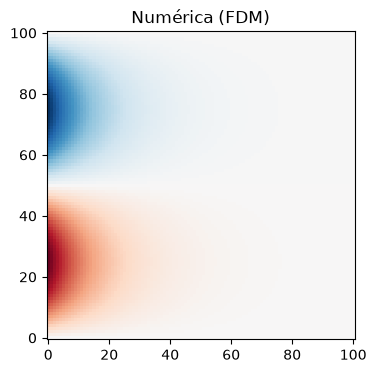

In [ ]:
# Parámetros
L = 100
Delta = 1
u0 = 100
N = int(L/Delta) + 1  # número de puntos

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)  # se cambia "infinito" en y = L, donde e^{-2*pi*y/L} ya es despreciable

# Condición inicial/de frontera
V_ini = np.zeros((N, N), float)
V_ini[:, 0] = u0 * np.sin(2*np.pi*x/L)   # u(x,0)
# u(0,y)=0, u(L,y)=0 y u(x,L)=0 ya quedan en cero por defecto

# Resolver con el método ya implementado
V_num = Laplace2D_FDM(V_ini, tol=1e-4, Nmax_iter=5000)

fig = plt.figure(figsize=(15, 4))

plt.imshow(V_num, origin='lower', cmap='RdBu_r', vmin=-100, vmax=100)
plt.title('Numérica (FDM)')

plt.show()

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

Convergió en 224 iteraciones


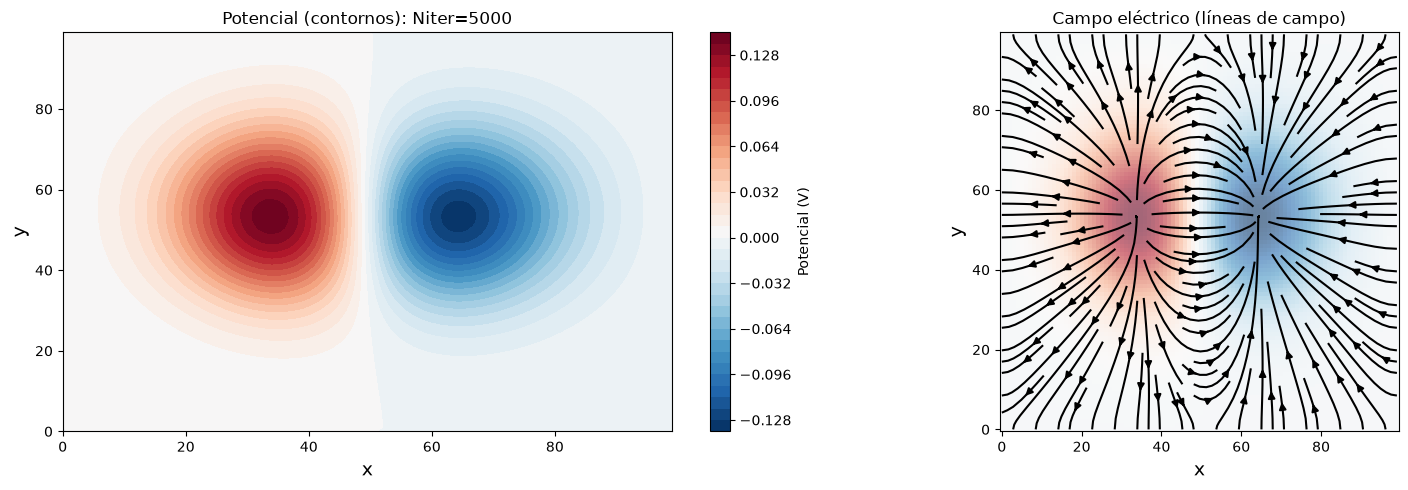

In [13]:
def capacitor(V0: float, Nmax: int, L: int, d: int, tol: float, Niter: int) -> np.ndarray:
    """
    Genera la malla inicial de un capacitor de placas paralelas y resuelve
    el potencial mediante diferencias finitas (Laplace2D_FDM).

    V0: voltaje de las placas (+V0 y -V0) -> float
    Nmax: tamaño de la malla (Nmax x Nmax) -> int
    L: longitud de las placas -> int
    d: separación entre placas -> int
    tol: tolerancia de convergencia -> float
    Niter: número máximo de iteraciones -> int

    Retorna -> np.ndarray: potencial V(x,y) convergido
    """
    centro = int((d + Nmax) / 2)
    V_ini = np.zeros((Nmax, Nmax), float)

    # Placas: una a +V0 y otra a -V0, separadas una distancia d
    fila_ini = centro - L // 2
    for k in range(L):
        V_ini[fila_ini + k, centro - d] = V0
        V_ini[fila_ini + k, centro] = -V0

    V_final = Laplace2D_FDM(V_ini, tol=tol, Nmax_iter=Niter)
    return V_final


# Parámetros
V0, Nmax, L, d = 50, 100, 10, 10
Niter = 5000
tol = 1e-3

V = capacitor(V0, Nmax, L, d, tol, Niter)

# Campo eléctrico E = -∇V (diferencias finitas centradas) como mencionó el profe en clase que intentaramos hacer
Ey, Ex = np.gradient(-V)

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Contornos del potencial
im0 = axs[0].contourf(V, levels=40, cmap='RdBu_r')
axs[0].set_title(f'Potencial (contornos): Niter={Niter}')
axs[0].set_xlabel("x", size=14)
axs[0].set_ylabel("y", size=14)
fig.colorbar(im0, ax=axs[0], label='Potencial (V)')

# líneas de campo sobre el potencial
axs[1].imshow(V, cmap='RdBu_r', origin='lower', alpha=0.6)
axs[1].streamplot(np.arange(Nmax), np.arange(Nmax), Ex, Ey, color='k', density=1.2)
axs[1].set_title('Campo eléctrico (líneas de campo)')
axs[1].set_xlabel("x", size=14)
axs[1].set_ylabel("y", size=14)

plt.tight_layout()
plt.show()